In [1]:
import os
# Get the current working directory
current_dir = os.getcwd()
# Set the data directory to the parent directory of the current working directory
wdir = os.path.dirname(current_dir)
# Change the current working directory to the parent directory
os.chdir(wdir)

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.gridspec import GridSpec
import numpy as np
from matplotlib import rcParams

from scipy.stats import norm



In [3]:
# Set the font globally
rcParams['font.family'] = 'Arial'
rcParams['font.size'] = 9
rcParams['axes.titlesize'] = 9
rcParams['axes.labelsize'] = 9
rcParams['xtick.labelsize'] = 9
rcParams['ytick.labelsize'] = 9
rcParams['legend.fontsize'] = 9

In [2]:
pwd()

'/Users/edwin/Documents/1-work_Riverside/John_Barton/Aaron_D/code/upload_code/notebooks'

In [8]:
# Load data
fraction_mut_variant_res_ = np.loadtxt("data/Supplementary_Fig_12/fraction_mut_variant_res.txt")
times_ = np.loadtxt("data/Supplementary_Fig_12/time.txt")
j1 = np.loadtxt("data/Supplementary_Fig_12/jump_1.txt")
j2 = np.loadtxt("data/Supplementary_Fig_12/jump_2.txt")
slope_ = np.loadtxt("data/Supplementary_Fig_12/slope.txt")
max_dif_slope_non_cd_ = np.loadtxt("data/Supplementary_Fig_12/max_dif_slope_non_cd.txt");


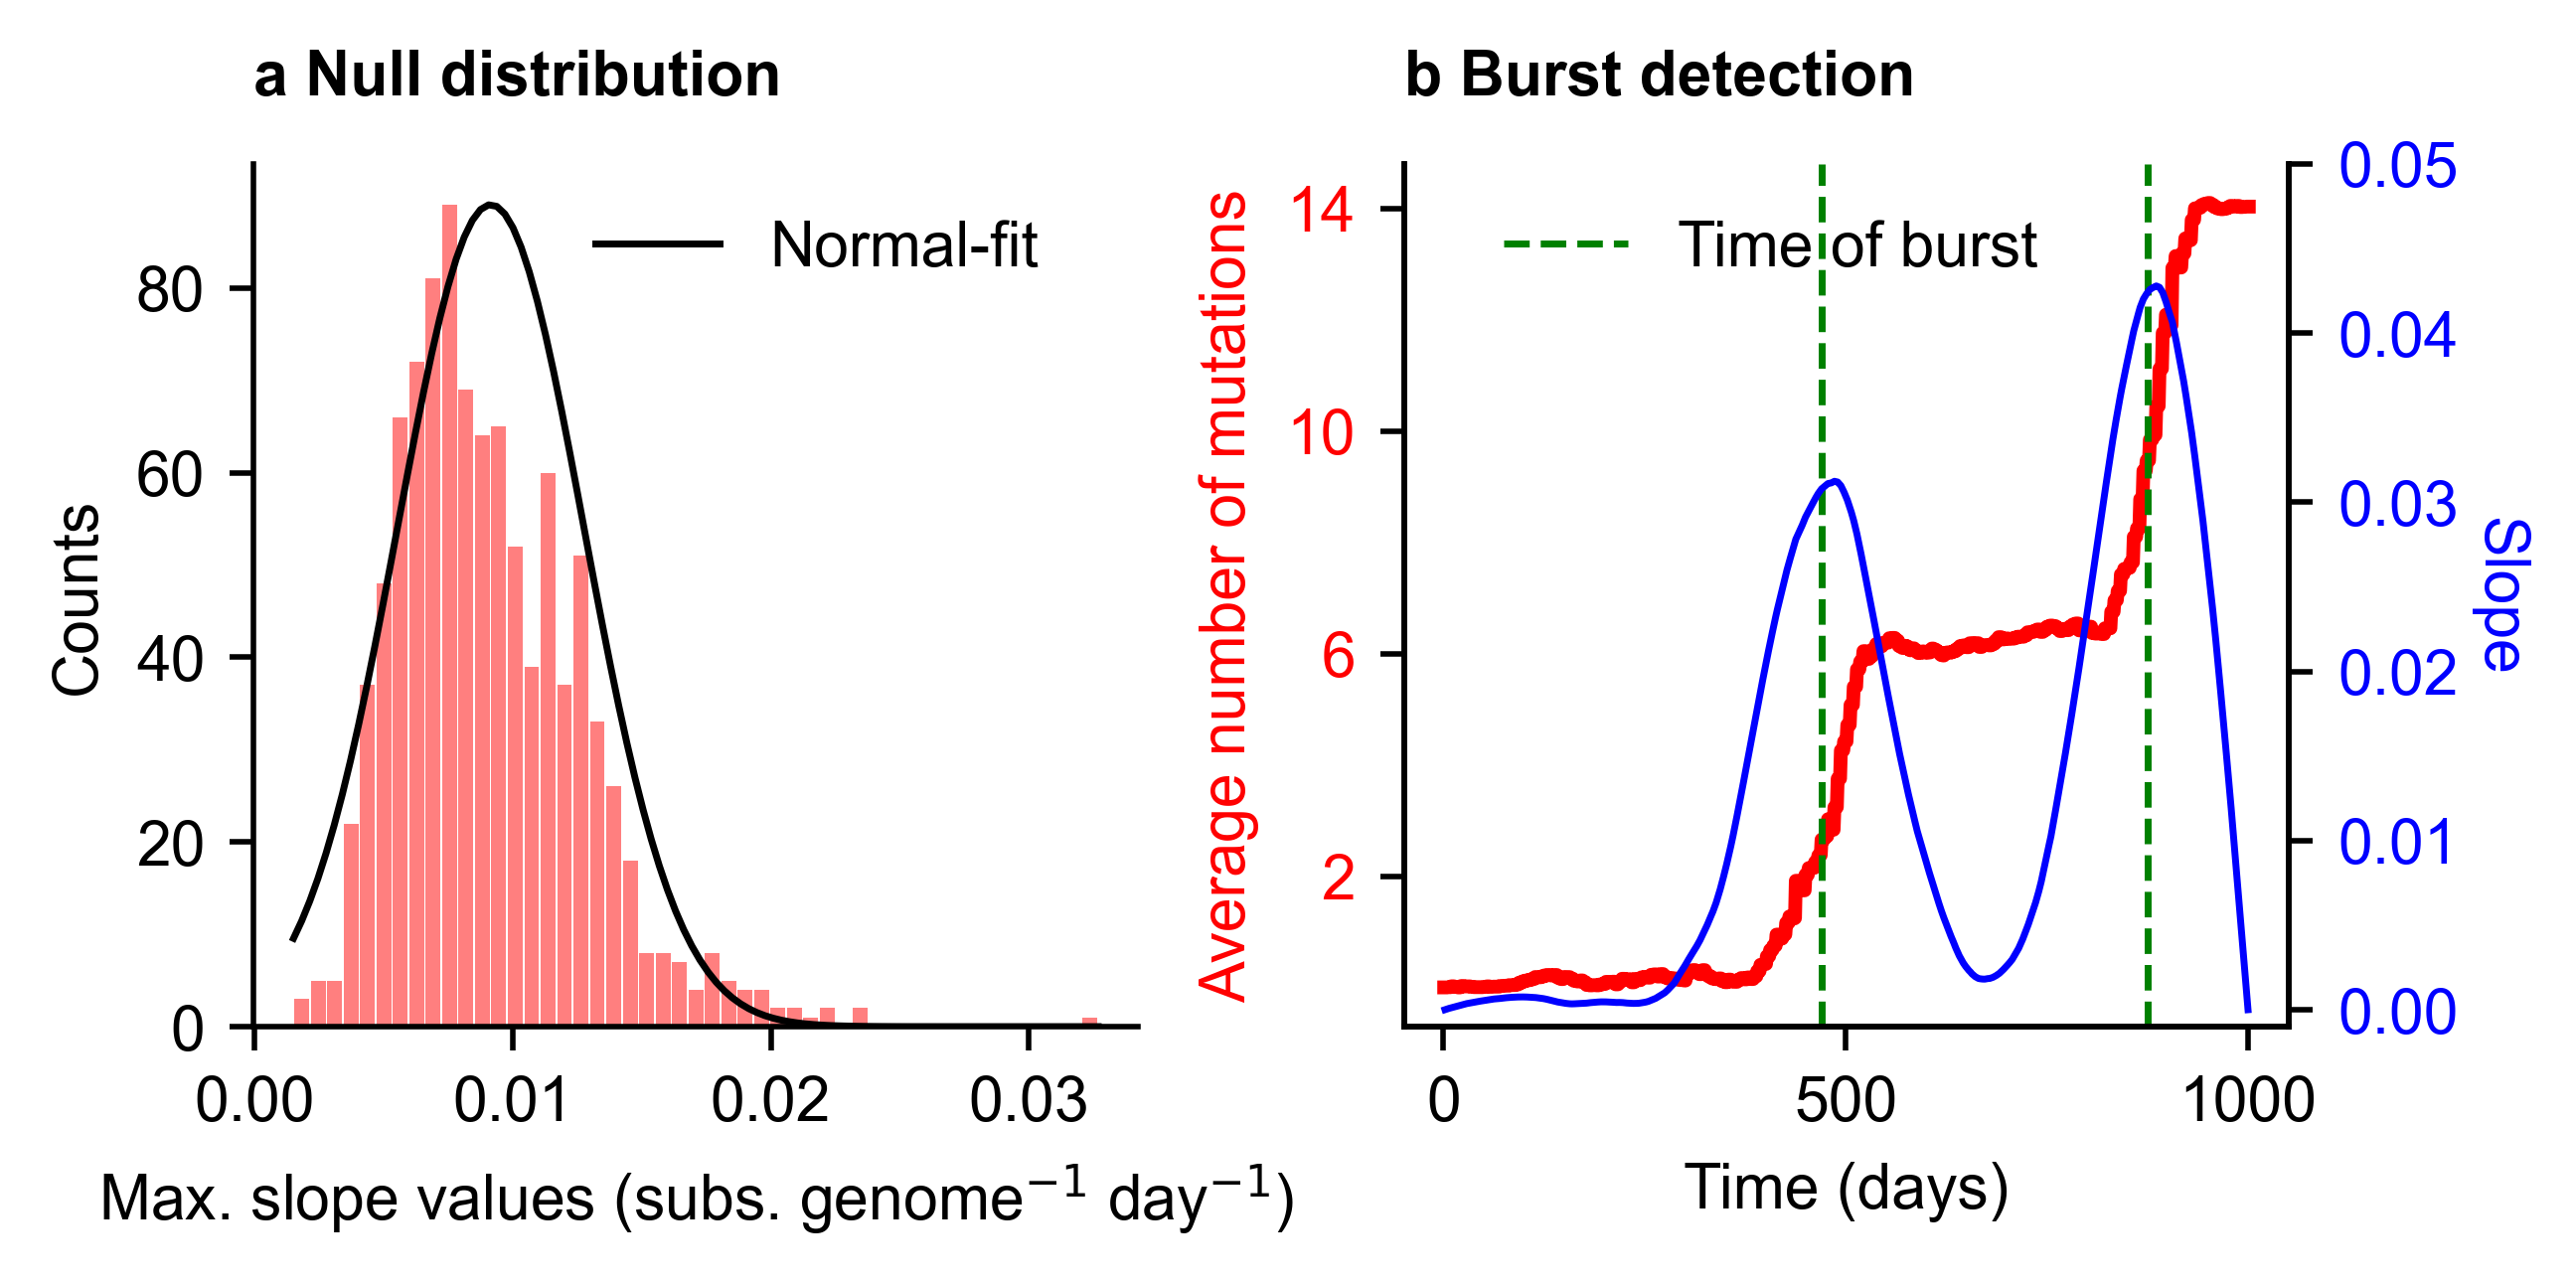

In [7]:
def cm2inch(x): return float(x)/2.54

plotwidth    = cm2inch(8.90)

# Fit a normal distribution to the data
dis_max = norm.fit(max_dif_slope_non_cd_)
bins = np.linspace(np.min(max_dif_slope_non_cd_), np.max(max_dif_slope_non_cd_), 50)

# Create a single figure with two subplots
fig, axs = plt.subplots(1, 2, figsize=(1.5*plotwidth, plotwidth),dpi=500)  # Adjust the figsize according to your layout

# Plot the histogram with PDF in the first subplot
# Plot the histogram with PDF in the first subplot
ax1 = axs[0]
hist_values, bin_edges, _ = ax1.hist(max_dif_slope_non_cd_, bins=bins, density=False, 
                                     color='red', edgecolor='none', rwidth=0.9, alpha=0.5, label="")

# Scale the normal PDF to match the histogram peak
x = np.linspace(np.min(max_dif_slope_non_cd_), np.max(max_dif_slope_non_cd_), 100)
p = norm.pdf(x, dis_max[0], dis_max[1])

# Scale the PDF so that it aligns with the histogram's highest bar
max_hist_value = np.max(hist_values)  # Find peak height of histogram
max_pdf_value = np.max(p)  # Find peak of unscaled PDF
scaled_p = p * (max_hist_value / max_pdf_value)  # Scale PDF

ax1.plot(x, scaled_p, color='black', linewidth=1, label="Normal-fit")

# Formatting
ax1.set_xlabel("Max. slope values (subs. genome$^{-1}$ day$^{-1}$)")
ax1.set_ylabel("Counts")
ax1.legend(loc='upper right',bbox_to_anchor=(0.95, 1.0),frameon=False)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Plot the time series in the second subplot
ax2 = axs[1]
ax2.plot(times_, fraction_mut_variant_res_, lw=2, color='red', label='')
ax2.set_xlabel("Time (days)")
ax2.set_ylabel("Average number of mutations", color='red')
ax2.tick_params(axis='y', labelcolor='red')
#axs[1].ylim([0, 12])

ax3 = ax2.twinx()
ax3.plot(times_[1:1000], slope_, lw=1, color='blue', label='')

ax3.set_ylabel("Slope", color='blue',rotation=270,labelpad=10)
ax3.tick_params(axis='y', labelcolor='blue')
ax3.set_ylim([-0.001, 0.05])

ax2.axvline(x=j1, color='green', lw=1, linestyle='dashed', label='Time of burst')
ax2.axvline(x=j2, color='green', lw=1, linestyle='dashed')
ax2.legend(loc='upper left',bbox_to_anchor=(0.05, 1.0),frameon=False)

ax3.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

axs[0].set_title('a Null distribution ', loc='left', fontname='Arial',pad=10,weight='bold')

axs[1].set_title('b Burst detection', loc='left', fontname='Arial',pad=10,weight='bold')

#fig.legend(loc='upper center')

# Customize margins and font sizes
fig.tight_layout()
plt.subplots_adjust(bottom=0.4,hspace=0.2,wspace=0.3)

#plt.subplots_adjust(top=0.9)
axs[1].set_yticks([2.0, 6.0,10.0,14.0])

# Show the plot
plt.show()
